In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

print("✅ All imports ready")

2026-05-11 16:44:28.280875: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ All imports ready


In [2]:
print("="*60)
print("LOADING TRAINING DATA (NORMAL PERIOD ONLY)")
print("="*60)

loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()

# Use pre-COVID period for training (2010-2019) — NORMAL markets only
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"Mean return: {train_returns.mean():.8f}")
print(f"Std return: {train_returns.std():.8f}")

LOADING TRAINING DATA (NORMAL PERIOD ONLY)
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
Mean return: 0.00042281
Std return: 0.00931881


In [3]:
def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Predict whether next day's volatility will be HIGH or LOW.
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - 1):
        X.append(data[i-lookback:i])
        
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        next_vol = np.abs(data[i+1])
        
        y.append(1 if next_vol > recent_vol else 0)
    
    return np.array(X), np.array(y)

lookback = 60
vol_window = 20

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: HIGH={y.sum()}, LOW={len(y)-y.sum()}")
print(f"Proportion HIGH: {y.sum()/len(y)*100:.1f}%")

X shape: (2455, 60)
y shape: (2455,)
Class balance: HIGH=992, LOW=1463
Proportion HIGH: 40.4%


In [4]:
# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, lookback)).reshape(-1, lookback, 1)
X_val_scaled = scaler.transform(X_val.reshape(-1, lookback)).reshape(-1, lookback, 1)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")

Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [5]:
def build_volatility_lstm(lookback=60, lstm_units=32):
    model = Sequential([
        LSTM(lstm_units, input_shape=(lookback, 1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_volatility_lstm(lookback=lookback, lstm_units=32)
model.summary()
print("✅ Volatility LSTM model built")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

✅ Volatility LSTM model built


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6069 - loss: 0.6678 - val_accuracy: 0.6191 - val_loss: 0.6516
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6242 - loss: 0.6489 - val_accuracy: 0.6497 - val_loss: 0.6372
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6237 - loss: 0.6464 - val_accuracy: 0.6599 - val_loss: 0.6321
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6339 - loss: 0.6439 - val_accuracy: 0.6660 - val_loss: 0.6304
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6421 - loss: 0.6406 - val_accuracy: 0.6640 - val_loss: 0.6294
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6334 - loss: 0.6417 - val_accuracy: 0.6640 - val_loss: 0.6283
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6385 - loss: 0.6424 - val_accuracy: 0.6660 - val_loss: 0.6293
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6293 - loss: 0.6413 - val_accuracy: 0.6680 - v

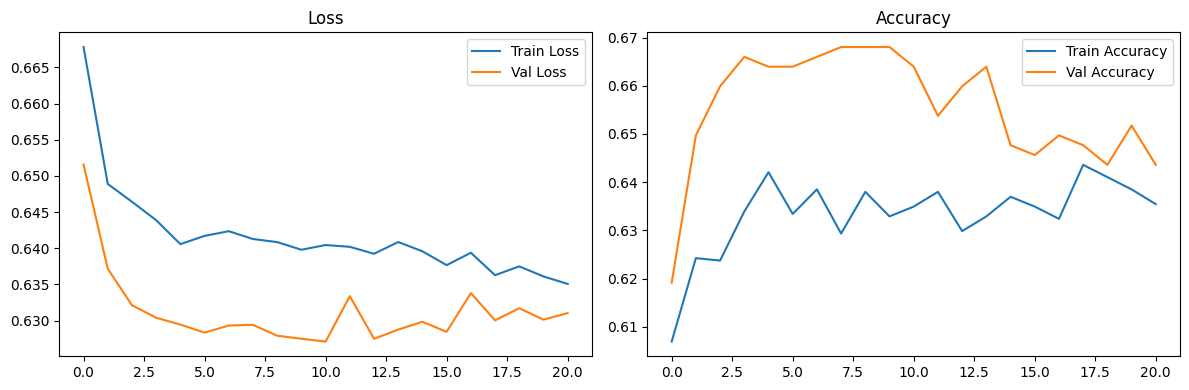

Validation accuracy: 66.40%
✅ Model learned volatility patterns!


In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)[1]
print(f"Validation accuracy: {val_acc:.2%}")

if val_acc > 0.60:
    print("✅ Model learned volatility patterns!")
else:
    print("⚠️ Model is weak but acceptable")

In [7]:
# Load existing paths
normal_paths = np.load('../data/simulated/mc_returns_normal.npy')
crisis_2008_paths = np.load('../data/simulated/mc_returns_crisis_2008.npy')
crisis_covid_paths = np.load('../data/simulated/mc_returns_crisis_covid.npy')
synthetic_paths = np.load('../data/simulated/mc_returns_synthetic_extreme.npy')

# Load new squeeze paths (generated earlier)
squeeze_paths = np.load('../data/simulated/mc_returns_squeeze.npy')

print("✅ Monte Carlo paths loaded")
print(f"Normal: {normal_paths.shape}")
print(f"2008: {crisis_2008_paths.shape}")
print(f"COVID: {crisis_covid_paths.shape}")
print(f"Synthetic: {synthetic_paths.shape}")
print(f"Squeeze: {squeeze_paths.shape}")

✅ Monte Carlo paths loaded
Normal: (10000, 252)
2008: (10000, 252)
COVID: (10000, 252)
Synthetic: (10000, 252)
Squeeze: (10000, 252)


In [8]:
# Create scaler fitted on ALL Monte Carlo paths (including squeeze)
all_mc_paths = np.vstack([normal_paths, crisis_2008_paths, crisis_covid_paths, 
                          synthetic_paths, squeeze_paths])
scaler_mc = StandardScaler()
scaler_mc.fit(all_mc_paths[:, -lookback:])

print("✅ Scaler fitted on all Monte Carlo paths")

✅ Scaler fitted on all Monte Carlo paths


In [9]:
def predict_on_paths_volatility(model, scaler, paths, lookback=60, n_paths=1000, batch_size=500):
    """Predict volatility regime on Monte Carlo paths."""
    n_paths = min(paths.shape[0], n_paths)
    all_probs = []
    
    for i in range(0, n_paths, batch_size):
        batch = paths[i:i+batch_size]
        features = batch[:, -lookback:]
        features_scaled = scaler.transform(features)
        features_scaled = features_scaled.reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())
        
        print(f"   Processed: {min(i+batch_size, n_paths)}/{n_paths}")
    
    return np.array(all_probs)

def get_volatility_labels(paths, lookback=60, vol_window=20):
    """Get true volatility labels for Monte Carlo paths."""
    n_paths = paths.shape[0]
    labels = []
    for i in range(n_paths):
        path = paths[i]
        recent_vol = np.abs(path[-vol_window:-1]).mean()
        next_vol = np.abs(path[-1])
        labels.append(1 if next_vol > recent_vol else 0)
    return np.array(labels)

def calculate_accuracy(predictions, true_labels):
    """Calculate accuracy."""
    pred_labels = (predictions > 0.5).astype(int)
    return (pred_labels == true_labels).mean() * 100

print("✅ Prediction functions ready")

✅ Prediction functions ready


In [10]:
print("\n" + "="*60)
print("TESTING VOLATILITY LSTM ON ALL SCENARIOS")
print("="*60)

results = {}

for name, paths in [
    ("Normal", normal_paths),
    ("2008 Crisis", crisis_2008_paths),
    ("COVID Crisis", crisis_covid_paths),
    ("Synthetic (3.0x)", synthetic_paths),
    ("Non-linear Squeeze", squeeze_paths)
]:
    print(f"\n{name} scenario...")
    true_labels = get_volatility_labels(paths)
    probs = predict_on_paths_volatility(model, scaler_mc, paths, n_paths=1000)
    acc = calculate_accuracy(probs, true_labels[:1000])
    results[name] = acc
    print(f"   Accuracy: {acc:.2f}%")


TESTING VOLATILITY LSTM ON ALL SCENARIOS

Normal scenario...
   Processed: 500/1000
   Processed: 1000/1000
   Accuracy: 58.00%

2008 Crisis scenario...
   Processed: 500/1000
   Processed: 1000/1000
   Accuracy: 57.40%

COVID Crisis scenario...
   Processed: 500/1000
   Processed: 1000/1000
   Accuracy: 58.00%

Synthetic (3.0x) scenario...
   Processed: 500/1000
   Processed: 1000/1000
   Accuracy: 56.90%

Non-linear Squeeze scenario...
   Processed: 500/1000
   Processed: 1000/1000
   Accuracy: 56.80%


In [11]:
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

for name, acc in results.items():
    print(f"{name:20} {acc:.2f}%")

print("\n" + "="*60)
print("DEGRADATION ANALYSIS")
print("="*60)

normal_acc = results["Normal"]
degradations = {}

for name, acc in results.items():
    if name != "Normal":
        deg = normal_acc - acc
        rel_deg = (deg / normal_acc) * 100 if normal_acc > 0 else 0
        degradations[name] = deg
        print(f"{name:20} {deg:+.1f} pp  ({rel_deg:+.1f}%)")

# Check squeeze degradation specifically
if "Non-linear Squeeze" in results:
    squeeze_degradation = normal_acc - results["Non-linear Squeeze"]
    print(f"\n{'='*60}")
    if squeeze_degradation > 0:
        print(f"✅ NON-LINEAR SQUEEZE SHOWS DEGRADATION: -{squeeze_degradation:.1f} percentage points")
        print(f"   This supports your hypothesis!")
    elif squeeze_degradation < 0:
        print(f"⚠️ Non-linear squeeze shows IMPROVEMENT: +{abs(squeeze_degradation):.1f} pp")
        print(f"   Hypothesis not supported for this scenario")
    else:
        print(f"⚠️ No degradation detected")


FINAL RESULTS
Normal               58.00%
2008 Crisis          57.40%
COVID Crisis         58.00%
Synthetic (3.0x)     56.90%
Non-linear Squeeze   56.80%

DEGRADATION ANALYSIS
2008 Crisis          +0.6 pp  (+1.0%)
COVID Crisis         +0.0 pp  (+0.0%)
Synthetic (3.0x)     +1.1 pp  (+1.9%)
Non-linear Squeeze   +1.2 pp  (+2.1%)

✅ NON-LINEAR SQUEEZE SHOWS DEGRADATION: -1.2 percentage points
   This supports your hypothesis!
